# Chương 7: Pre-training

Pre-training là nền tảng của NLP hiện đại — train mô hình trên dữ liệu lớn không nhãn, sau đó thích nghi cho các task cụ thể. Đây là cuộc cách mạng thay đổi hoàn toàn paradigm NLP: từ "train từ đầu cho mỗi task" sang "pre-train một lần, dùng cho nhiều task".

---

# 7.1 Pre-training trong NLP

## Framework Thống Nhất

$$o = g_\theta(x_0, x_1, \ldots, x_m) \tag{7.1}$$

- $\{x_0, x_1, \ldots, x_m\}$: chuỗi tokens, $x_0 = \langle s\rangle$ hoặc $[\text{CLS}]$
- $g_\theta(\cdot)$: neural network với tham số $\theta$
- $o$: output — có thể là phân phối từ (generation) hoặc sequence of vectors (encoding)

**Hai khía cạnh cốt lõi:**
1. **Optimize $\theta$** cho pre-training task (không cần biết downstream task)
2. **Adapt $\hat{\theta}$** cho downstream task qua fine-tuning hoặc prompting

---

## 7.1.1 Ba Loại Pre-training

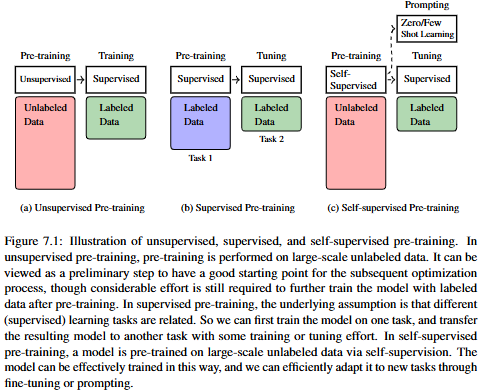

### Unsupervised Pre-training

Train neural network trên unlabeled data với tiêu chí không liên quan đến task cụ thể (ví dụ: minimize reconstruction cross-entropy).

**Vai trò:** Điểm khởi đầu tốt hơn cho supervised learning, regularization effect.

**Hạn chế:** Cần nhiều công sức supervised learning tiếp theo.

### Supervised Pre-training

Train trên task có nhãn thứ nhất, transfer sang task thứ hai.

**Ví dụ:** Pre-train sequence encoder trên sentiment analysis → fine-tune cho subjective/objective classification.

**Hạn chế:** Khi model phức tạp, cần nhiều labeled data — không scalable.

### Self-supervised Pre-training ← Dominant hiện nay

**Ý tưởng:** Tạo supervisory signal từ **chính dữ liệu** — không cần human annotation.

**Ví dụ:** Mask một số tokens → train model dự đoán chúng từ context xung quanh.

**Điểm khác với self-training truyền thống:**
- Không cần initial model để tạo pseudo-labels
- Supervision signal từ raw text, không phải discrete pseudo-labels
- Train toàn bộ model từ đầu

**Kết quả:** BERT, GPT và các LLM hiện đại đều theo paradigm này.

---

## 7.1.2 Hai Cách Thích Nghi Pre-trained Model

### 1. Fine-tuning

**Quy trình cho sequence encoding:**

**Bước 1 — Encode với pre-trained model:**
$$H = \text{Encode}_{\hat{\theta}}(x) \tag{7.2}$$

**Bước 2 — Thêm task-specific classifier:**
$$\Pr_{\omega,\hat{\theta}}(\cdot \mid x) = \text{Classify}_\omega(H) = \text{Classify}_\omega(\text{Encode}_{\hat{\theta}}(x)) \tag{7.3}$$

**Bước 3 — Fine-tune trên labeled data:**
- **Full fine-tuning:** Optimize cả $\omega$ và $\hat{\theta}$ → $\tilde{\omega}, \tilde{\theta}$
- **Frozen encoder:** Chỉ optimize $\omega$, giữ $\hat{\theta}$ cố định → nhanh hơn

**Ưu điểm:** Lượng labeled data cần cho fine-tuning **rất nhỏ** so với pre-training → hiệu quả cao.

**Ví dụ thực tế:**
```
Input: "I love the food here. It's amazing!"
→ Tokenize → F_{~ω,~θ}(x)
→ [Pr(positive)=0.92, Pr(negative)=0.03, Pr(neutral)=0.05]
→ Output: positive
```

### 2. Prompting

Dùng cho **sequence generation models (LLM)** — không cần thêm classifier, chỉ cần thiết kế prompt phù hợp.

**Zero-shot prompting** — mô tả task trong prompt:
```
Assume that the polarity of a text is a label chosen from 
{positive, negative, neutral}. Identify the polarity of the input.
Input: I love the food here. It's amazing!
Polarity: [model completes → "Positive"]
```

**Few-shot / In-context Learning (ICL)** — thêm demonstrations vào prompt:
```
Input: The traffic is terrible...    Polarity: Negative
Input: The weather here is wonderful. Polarity: Positive
Input: I love the food here...        Polarity: [→ Positive]
```

Model học từ demonstrations ngay trong context window — **không cập nhật tham số**.

---

## So Sánh Fine-tuning vs Prompting

| | Fine-tuning | Prompting/ICL |
|---|---|---|
| **Cập nhật tham số** | Có | Không |
| **Cần labeled data** | Ít (nhưng vẫn cần) | Không (zero-shot) hoặc rất ít |
| **Task coverage** | Tốt cho task cụ thể | Linh hoạt, đa task |
| **Phù hợp với** | Encoder models (BERT) | Large LLMs (GPT) |
| **Chi phí** | Train lại model | Chỉ cần thiết kế prompt |

---

## Tổng Kết Mục 7.1

```
Pre-training Paradigm:

1. Self-supervised pre-train trên unlabeled data lớn
   → gθ học general linguistic knowledge

2. Adapt cho downstream tasks:
   
   Sequence Encoding (BERT-style):
     Encode_θ(x) → H → Classify_ω(H)
     Fine-tune (ω, θ) trên labeled data
   
   Sequence Generation (GPT-style):
     Prompting: thiết kế input → model completes
     Zero-shot: mô tả task trong prompt
     Few-shot (ICL): thêm demonstrations
```

**Tầm quan trọng của paradigm này:**
- Không còn cần large labeled dataset cho mỗi task
- Một pre-trained model → hàng trăm downstream tasks
- Foundation models: BERT, GPT, T5, LLaMA,...

Bạn gửi tiếp nội dung 7.2 (Self-supervised Pre-training Tasks) nhé!

# 7.2 Các Tác Vụ Pre-training Tự Giám Sát (Self-supervised Pre-training Tasks)

---

## 7.2.1 Decoder-only Pre-training

**Kiến trúc:** Transformer decoder bỏ cross-attention → **language model thuần túy**.

**Tác vụ:** Dự đoán token tiếp theo từ context trước đó (causal/autoregressive LM).

**Hàm mục tiêu — Cross-entropy loss trên chuỗi $x = \{x_0,\ldots,x_m\}$:**

$$\text{Loss}_\theta(x_0,\ldots,x_m) = \sum_{i=0}^{m-1} \text{CrossEntropy}(p_{i+1}^{\theta}, p_{i+1}^{\text{gold}}) \tag{7.5}$$

**Maximum Likelihood Estimation tương đương:**

$$\hat{\theta} = \arg\max_\theta \sum_{x \in D} \sum_{i=0}^{|x|-2} \log \Pr_\theta(x_{i+1} \mid x_0,\ldots,x_i) \tag{7.7}$$

**Đặc điểm:**
- Causal masking: vị trí $i$ chỉ nhìn $x_0\ldots x_i$, không nhìn tương lai
- Supervision signal từ chính chuỗi: token $x_{i+1}$ là label của bước $i$
- **Dùng cho:** GPT series, LLaMA — decoder-only LLMs

---

## 7.2.2 Encoder-only Pre-training

**Vấn đề:** Encoder sinh ra sequence of vectors $H$ — không có ground-truth labels cho $H$. Giải pháp: kết hợp encoder với output layer → tạo supervisory signal.

$$\begin{pmatrix}p_1^{W,\theta}\\\vdots\\p_m^{W,\theta}\end{pmatrix} = \text{Softmax}_W(\text{Encode}_\theta(x)) \tag{7.8}$$

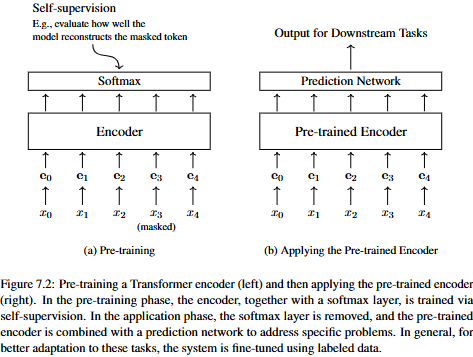

---

### 1. Masked Language Modeling (MLM) — Nền tảng của BERT

**Ý tưởng:** Mask một số tokens → train model dự đoán chúng từ context hai chiều.

**Quy trình:**
1. Chọn subset vị trí $A(x) = \{i_1,\ldots,i_u\}$
2. Thay các tokens tại $A(x)$ bằng `[MASK]` → chuỗi $\bar{x}$
3. Train model dự đoán $x_{i_k}$ từ **toàn bộ** $\bar{x}$

**Ví dụ:**
```
Gốc:   The early bird catches the worm
Masked: The [MASK] bird catches the [MASK]
→ Model dự đoán: "early" tại vị trí 2, "worm" tại vị trí 6
```

**Hàm mục tiêu:**

$$(\hat{W}, \hat{\theta}) = \arg\min_{W,\theta} \sum_{x \in D} \sum_{i \in A(x)} \text{CrossEntropy}(p_i^{W,\theta}, p_i^{\text{gold}}) \tag{7.10}$$

Loss tính:

$$\text{Loss} = \log\Pr(x_2=\text{early} \mid \bar{x}) + \log\Pr(x_6=\text{worm} \mid \bar{x}) \tag{7.11}$$

**Khác biệt với Causal LM:**
- **Causal LM:** chỉ nhìn **trái** → unidirectional
- **MLM:** nhìn **toàn bộ** (trừ masked positions) → **bidirectional**

**Sau training:** Bỏ $\hat{W}$ (softmax layer), giữ $\hat{\theta}$ (encoder) để fine-tune.

---

### 2. Permuted Language Modeling (PLM) — XLNet

**Vấn đề của MLM:**
- `[MASK]` token chỉ có trong training, không có trong inference → train/test mismatch
- Các masked tokens được dự đoán **độc lập** nhau — bỏ qua phụ thuộc giữa chúng

**Giải pháp — PLM:** Giữ nguyên chuỗi, thay đổi **thứ tự dự đoán** (factorization order).

**So sánh với causal LM** trên chuỗi $x_0x_1x_2x_3x_4$:

**Standard causal LM:**

$$\Pr(x) = \Pr(x_0)\cdot\Pr(x_1|e_0)\cdot\Pr(x_2|e_0,e_1)\cdot\Pr(x_3|e_0,e_1,e_2)\cdot\Pr(x_4|e_0,e_1,e_2,e_3) \tag{7.14}$$

**PLM với order $x_0 \to x_4 \to x_2 \to x_1 \to x_3$:**

$$\Pr(x) = \Pr(x_0)\cdot\Pr(x_4|e_0)\cdot\Pr(x_2|e_0,e_4)\cdot\Pr(x_1|e_0,e_4,e_2)\cdot\Pr(x_3|e_0,e_4,e_2,e_1) \tag{7.15}$$

Khi dự đoán $x_3$: context gồm cả $e_0,e_1,e_2$ (trái) và $e_4$ (phải) → **tương tự MLM nhưng không cần [MASK]**.

**Cài đặt:** Vì self-attention permutation-invariant, chỉ cần set attention masks phù hợp, không cần xáo thứ tự input thực sự:

```
Khi dự đoán x₁ với order x₀→x₄→x₂→x₁→x₃:
x₁ được attend bởi: x₀, x₄, x₂ ✓
x₁ KHÔNG attend tới: x₃ (chưa đến lượt)
```
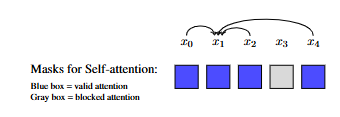

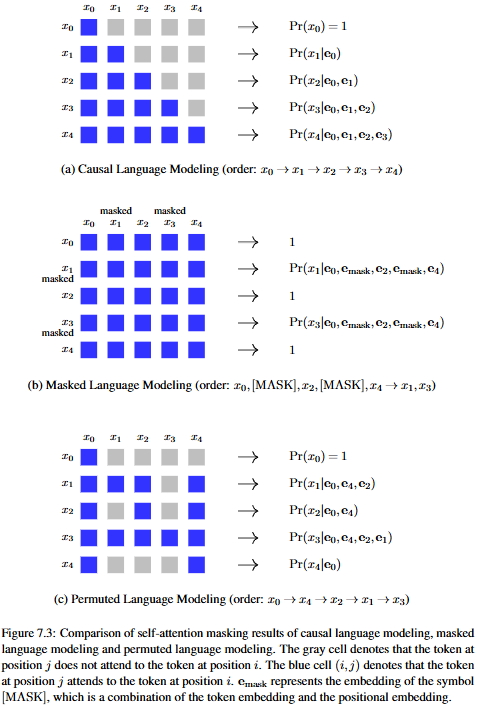

---

### 3. Pre-training Encoders như Classifiers

#### Next Sentence Prediction (NSP) — BERT

**Ý tưởng:** Encoder tốt nên hiểu quan hệ giữa hai câu.

**Tác vụ:** Phân biệt hai câu có thực sự liên tiếp hay không.

```
Input:  [CLS] It is raining . [SEP] I need an umbrella . [SEP]
→ Encoder → h₀ (global repr) → Softmax → IsNext / NotNext
```

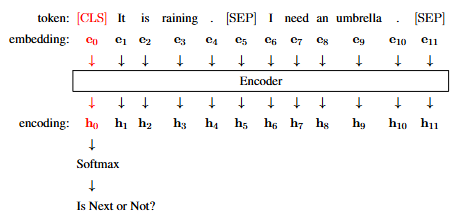

**Tạo training data:**
- **Positive:** Hai câu liên tiếp thực trong corpus
- **Negative:** Ghép câu thứ hai với câu ngẫu nhiên từ corpus khác

NSP thường dùng như **auxiliary loss** kết hợp với MLM.

#### ELECTRA — Replaced Token Detection

**Vấn đề của MLM:** Chỉ học từ ~15% tokens bị mask → không hiệu quả.

**Ý tưởng:** Train model phân biệt **từng token** có bị thay thế hay không → học từ **100% tokens**.

**Quy trình hai bước:**

**Bước 1 — Generator (small MLM):**

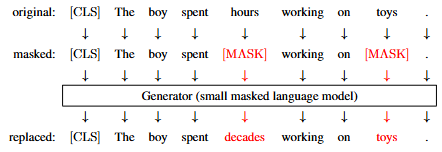

```
Original:   [CLS] The boy spent hours  working on toys .
Masked:     [CLS] The boy spent [MASK] working on [MASK] .
Generator → [CLS] The boy spent decades working on toys  .
                                  ^replaced         ^same
```

**Bước 2 — Discriminator (model ta muốn):**

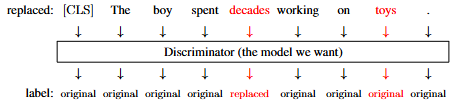

```
Input:  [CLS] The boy spent decades working on toys .
Output: orig  orig orig orig replaced orig   orig orig orig
```

**Training:**
- Generator: maximize likelihood (MLM loss)
- Discriminator: binary cross-entropy tại mỗi token

**Sau training:** Bỏ generator, giữ **discriminator encoder** cho downstream tasks.

**Ưu điểm ELECTRA so với BERT:** Học signal từ **mọi token** → hiệu quả data hơn → performance tốt hơn với cùng compute.

---

## 7.2.3 Encoder-Decoder Pre-training

### Text-to-Text Framework — T5

**Ý tưởng cốt lõi:** Mọi NLP task đều biểu diễn dạng **Source Text → Target Text**.

**Ví dụ các task:**
```
Translation:
[CLS] Translate from Chinese to English: 你好！→ ⟨s⟩ Hello!

Question Answering:
[CLS] Answer: when was Albert Einstein born?
→ ⟨s⟩ He was born on March 14, 1879.

Text Simplification:
[CLS] Simplify: the professor, who has published...
→ ⟨s⟩ The experienced professor will give a lecture next week.

Textual Entailment:
[CLS] Text: John bought a new car. Hypothesis: John has a car.
→ ⟨s⟩ Entailment

Translation Scoring (continuous → text generation):
[CLS] Score the translation: English: ... Chinese: ...
→ ⟨s⟩ 0.81
```

**Lợi ích:** Một mô hình duy nhất cho nhiều tasks, zero-shot generalization qua instruction.

---

### 1. Masked Encoder-Decoder Pre-training

**Prefix Language Modeling:**
```
Encoder: [CLS] The puppies are frolicking (prefix)
Decoder: ⟨s⟩ outside the house . (subsequent sequence)
```
Encoder học **hiểu prefix**, decoder học **tiếp tục sinh** từ prefix đó.

**BERT-style masking cho encoder-decoder:**
```
Input (encoder): [CLS] The puppies are [M] outside [M] house .
Output (decoder): ⟨s⟩ frolicking the
```
Decoder chỉ dự đoán các masked tokens.

**Denoising autoencoding — full sequence reconstruction:**
```
Input (encoder): [CLS] The puppies are [MASK] outside [MASK] house .
Output (decoder): ⟨s⟩ The puppies are frolicking outside the house .
```
Decoder reconstruct **toàn bộ chuỗi gốc** → học cả understanding (encoder) lẫn generation (decoder).

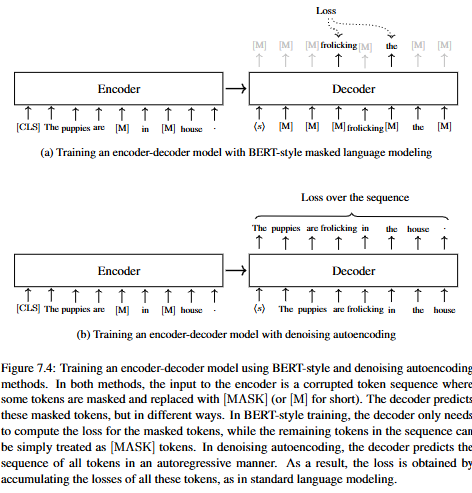

**Span masking với sentinel tokens (T5 style):**

Thay nhiều consecutive tokens bằng sentinel token duy nhất → chuỗi ngắn hơn → training hiệu quả hơn:
```
Original:  The puppies are frolicking outside the house .
Span mask: The puppies are [X] outside [Y] .
Output:    [X] frolicking [Y] the house [Z]
```
$[X], [Y], [Z]$ là sentinel tokens đại diện cho một hoặc nhiều tokens.

---

### 2. Denoising Training — BART

**Framework tổng quát:**

$$y = \text{Model}_{\theta,\omega}(x_{\text{noise}}), \quad (\hat{\theta},\hat{\omega}) = \arg\min_{\theta,\omega}\text{Loss}(\text{Model}_{\theta,\omega}(x_{\text{noise}}), x) \tag{7.16, 7.17}$$

**Các cách corrupt input (BART):**

**Token Masking:** Thay tokens bằng `[MASK]` — giống BERT.

**Token Deletion:** Xóa hoàn toàn (không để lại placeholder):
```
Original:   The puppies are frolicking outside the house .
Deletion:   The puppies are frolicking outside the house .
            (underlined tokens bị xóa hẳn, không có [MASK])
```

**Span Masking:** Mask cả span liên tiếp bằng một `[MASK]`:
```
Original:   The 0 puppies are frolicking outside the house .
Span mask:  The [M] puppies are [M] house .
            (span "frolicking outside the" → một [M]; 0=length-0 → insert [M])
```

**Sentence Reordering:** Hoán đổi thứ tự các câu trong document:
```
Original: Hard work leads to success . Success brings happiness .
Reordered: Success brings happiness . Hard work leads to success .
```

**Document Rotation:** Xoay document bắt đầu từ token ngẫu nhiên:
```
Selected token: "leads"
Rotated: leads to success . Success brings happiness . Hard work Hard work
```

---

## 7.2.4 So Sánh Tổng Quan Các Pre-training Tasks

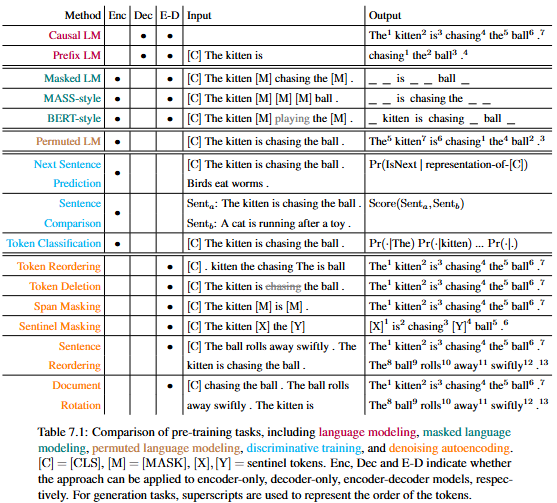

**Tóm tắt các phương pháp theo objective:**

| Phương pháp | Kiến trúc | Input | Output | Ví dụ model |
|---|---|---|---|---|
| **Causal LM** | Dec, E-D | $x_0\ldots x_i$ | $x_{i+1}$ | GPT, LLaMA |
| **Prefix LM** | Dec, E-D | prefix | subsequent tokens | PaLM |
| **Masked LM** | Enc | $\bar{x}$ (masked) | masked tokens | BERT, RoBERTa |
| **Permuted LM** | Enc | $x$ (reordered predict) | tokens in perm order | XLNet |
| **NSP** | Enc | $[\text{CLS}] S_A [\text{SEP}] S_B [\text{SEP}]$ | IsNext/NotNext | BERT |
| **Token Discrimination** | Enc | replaced sequence | orig/replaced per token | ELECTRA |
| **Denoising AE** | E-D | corrupted $x$ | original $x$ | BART, T5 |

---

## Tổng Kết Mục 7.2

```
Pre-training Task Taxonomy:

DECODER-ONLY (GPT, LLaMA):
  Causal LM: Pr(xᵢ₊₁|x₀...xᵢ) — autoregressive, causal mask
  Objective: maximize Σ log Pr(xᵢ₊₁|x₀...xᵢ)

ENCODER-ONLY (BERT, XLNet, ELECTRA):
  Masked LM: predict masked tokens from bidirectional context
    ĥ = arg max Σ_{i∈A(x)} log Pr(xᵢ|x̄)
  Permuted LM: predict tokens in random order (no [MASK])
  NSP: IsNext classification → inter-sentence understanding
  Token Discrimination: original/replaced per token (ELECTRA)

ENCODER-DECODER (T5, BART):
  Prefix LM: encoder reads prefix, decoder continues
  Denoising AE: encoder reads corrupted, decoder reconstructs
  Span Masking + Sentinel: efficient span-level prediction
  BART-style corruptions: token deletion, sentence reorder, doc rotation

Key trade-offs:
  Causal LM vs MLM:
    Causal: no train/test mismatch, natural generation
    MLM: bidirectional context → better understanding
  MLM vs PLM:
    MLM: simple, efficient; trains each mask independently
    PLM: no [MASK] mismatch; models inter-token dependencies
  MLM vs ELECTRA:
    MLM: learns from 15% tokens only
    ELECTRA: learns from 100% tokens → more efficient
```

# 7.3 Ví Dụ: BERT

---

## 7.3.1 Pre-training BERT

### Tác Vụ Pre-training

BERT kết hợp **hai tác vụ** pre-training đồng thời:

**Tác vụ 1 — Masked Language Modeling (MLM):**

**Quy trình 3 bước để xử lý 15% tokens được chọn:**

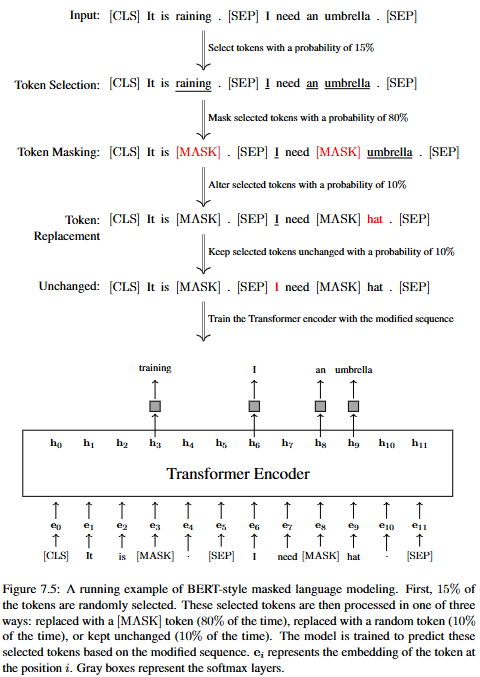

| Xử lý | Tỷ lệ | Mục đích |
|---|---|---|
| **[MASK]** | 80% | Tạo prediction challenge chính |
| **Random token** | 10% | Buộc encoder duy trì representation có nghĩa (không phụ thuộc [MASK]) |
| **Unchanged** | 10% | Giảm train/test mismatch — fine-tuning không có [MASK] |

**Ví dụ:**
```
Input:      [CLS] It is raining . [SEP] I need an umbrella . [SEP]
Selected:         *        *                         *
Masked:     [CLS] It is [MASK] . [SEP] I need [MASK] hat     . [SEP]
                  (masked)              (masked) (random)
Predict:    raining (position 3), an (position 8), umbrella (position 9)
```

**Loss function MLM:**

$$\text{Loss}_{\text{mlm}} = -\sum_{i \in A(x)} \log\Pr_i(x_i \mid \bar{x}) \tag{7.19}$$

**Tác vụ 2 — Next Sentence Prediction (NSP):**

Dùng $h_0$ (output tại `[CLS]`) → binary classifier IsNext/NotNext:

$$\text{Loss}_{\text{nsp}} = -\log\Pr(c_{\text{gold}} \mid h_{\text{cls}}) \tag{7.20}$$

**Tổng loss:** $\text{Loss}_{\text{BERT}} = \text{Loss}_{\text{mlm}} + \text{Loss}_{\text{nsp}}$

---

### Embedding Layer

$$e = x + e_{\text{pos}} + e_{\text{seg}} \tag{7.21}$$

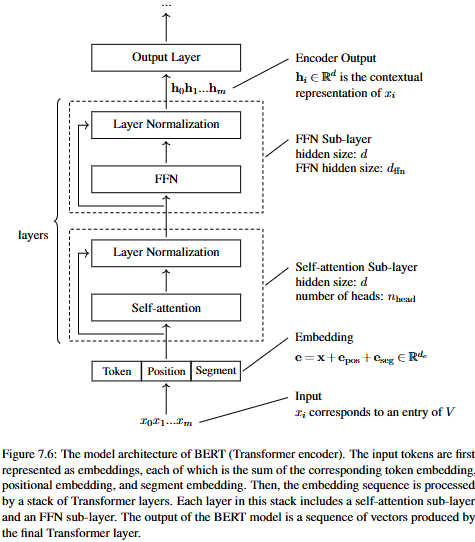

**Ba thành phần embedding:**

| | Mô tả | Đặc điểm |
|---|---|---|
| **Token embedding $x$** | Embedding của từng token | Giống Transformer gốc |
| **Positional embedding $e_{\text{pos}}$** | Mã hóa vị trí | Giống Transformer gốc |
| **Segment embedding $e_{\text{seg}}$** | Phân biệt SentA/SentB | **Mới** — dùng cho NSP |

**Ví dụ segment embedding:**

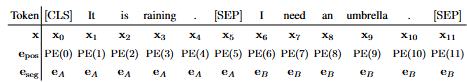

---

### Cấu Hình Model

**Các hyperparameter chính:**

| Param | Ý nghĩa | BERTbase | BERTlarge |
|---|---|---|---|
| $d$ | Hidden size (width) | 768 | 1024 |
| $L$ | Số layers (depth) | 12 | 24 |
| $n_{\text{head}}$ | Số attention heads | 12 | 16 |
| $d_{\text{ffn}}$ | FFN hidden size | 3072 ($4d$) | 4096 ($4d$) |
| **Total params** | | **110M** | **340M** |

**Kiến trúc:** Post-norm Transformer encoder — $\text{output} = \text{LNorm}(F(\text{input}) + \text{input})$

**Kỹ thuật training thực tế:** Pre-train trên chuỗi ngắn trước → sau đó full-length sequences → tăng hiệu quả training.

---

## 7.3.2 RoBERTa — Scale up BERT

**Hai cải tiến chính:**

1. **Nhiều data + compute hơn** — không thay đổi kiến trúc → vẫn cải thiện đáng kể
2. **Bỏ NSP loss** — không làm giảm performance khi scale up

**Kết luận:** Pre-training cải thiện được đơn giản bằng cách **scale lên** trên các tác vụ đơn giản.

---

## 7.3.3 Các Biến Thể Hiệu Quả Hơn

**Bốn hướng chính để làm BERT nhỏ và nhanh hơn:**

**1. Knowledge Distillation** — Transfer knowledge từ BERT lớn sang BERT nhỏ (student):
- Distill từ output layer
- Distill từ hidden layer representations (DistilBERT, TinyBERT)

**2. Pruning:**
- Xóa toàn bộ layers
- Xóa % parameters trong network
- Prune attention heads — Michel et al. (2019): nhiều heads không cần thiết, bỏ đi không ảnh hưởng nhiều

**3. Dynamic Networks — Adaptive Depth/Length:**
- **Depth-adaptive:** Early exit tại layer tối ưu, bỏ qua phần còn lại
- **Length-adaptive:** Skip tokens ít quan trọng → giảm sequence length

**4. Parameter Sharing:**
- Dùng cùng tham số cho tất cả Transformer layers (ALBERT)
- Giảm số tham số đáng kể + tiết kiệm memory

---

## 7.3.4 Multilingual BERT (mBERT, XLM)

### Động Lực

Thay vì train riêng model cho từng ngôn ngữ → train một model trên **nhiều ngôn ngữ cùng lúc** → shared representations → cross-lingual transfer.

**mBERT:** Train trên 104 ngôn ngữ — vocabulary dùng chung → tokens các ngôn ngữ map vào cùng không gian vector.

### Cross-lingual Zero-shot Transfer

Train trên English labeled data → trực tiếp apply sang Chinese (hoặc ngôn ngữ khác) **không cần labeled data đích** — nhờ shared multilingual representation space.

### Translation Language Modeling (TLM) — XLM

**Ý tưởng:** Đưa **cặp câu song ngữ** vào training → buộc model học alignment giữa hai ngôn ngữ.

**Quy trình:**
```
Aligned pair:   鲸鱼是哺乳动物。↔ Whales are mammals.
Packed:  [CLS] 鲸鱼是哺乳动物。[SEP] Whales are mammals. [SEP]
Masked:  [CLS] [M] 是 [M] 动物。[SEP] Whales [M] [M]. [SEP]
```

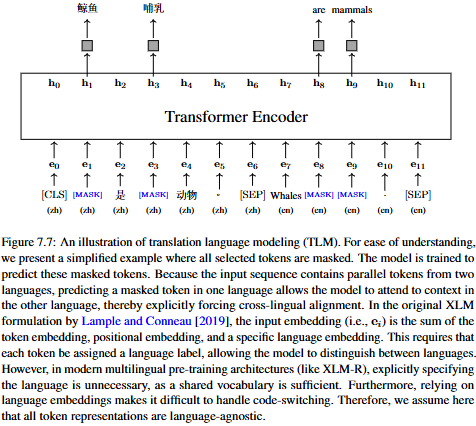

**Tại sao TLM hiệu quả:** Dự đoán token bị mask trong tiếng Trung có thể tận dụng context từ tiếng Anh → buộc model học **cross-lingual alignment tường minh**.

### Code-switching

Multilingual models tự nhiên xử lý **mixed-language text**:
```
"周末我们打算去做hiking，你想一起来吗？"
(Trung + English: "hiking" là tiếng Anh embedded trong câu Trung)
```
Mọi token đều là entry trong shared vocabulary → không cần identify ngôn ngữ.

### Curse of Multilinguality

**Trade-off quan trọng:** Thêm nhiều ngôn ngữ → competition tham số → performance trên high-resource languages giảm.

**Giải pháp thực tế:**
- Vocabulary lớn hơn → cover diversity tốt hơn
- Model lớn hơn → dung lượng đủ cho nhiều ngôn ngữ
- Ưu tiên include linguistically similar languages → cross-lingual transfer tốt hơn cho low-resource languages

---

## Tổng Kết Mục 7.3

```
BERT Architecture:
  Input: e = x + epos + eseg   (3 embeddings)
  Stack L Transformer encoder layers (Post-norm)
  Output: h₀...hm (contextual representations)

Pre-training:
  MLM: mask 15% tokens (80% [MASK], 10% random, 10% unchanged)
       → bidirectional context, predict masked tokens
  NSP: IsNext/NotNext từ h₀ (CLS token)
  Loss = Loss_mlm + Loss_nsp

Variants:
  RoBERTa:    scale data/compute + remove NSP → better
  DistilBERT: knowledge distillation → smaller, faster
  ALBERT:     parameter sharing + factorized embedding
  ELECTRA:    replaced token detection → more efficient

Multilingual:
  mBERT:  104 languages, shared vocab
  XLM:    + Translation LM (bilingual pairs)
  XLM-R:  + more data, no language embeddings needed
  
  Key property: zero-shot cross-lingual transfer
  Risk: curse of multilinguality (capacity interference)

BERTbase vs BERTlarge:
  base:  d=768, L=12, nhead=12, 110M params
  large: d=1024, L=24, nhead=16, 340M params
```

# 7.4 Áp Dụng BERT cho Các NLP Tasks

---

## Framework Tổng Quát Fine-tuning

$$y = \text{Predict}_\omega(\text{BERT}_{\hat{\theta}}(x)) \tag{7.22}$$

**Fine-tuning trên labeled data $D$:**

$$(\tilde{\omega}, \tilde{\theta}) = \arg\min_{\omega, \hat{\theta}+} \sum_{(x, y_{\text{gold}}) \in D} \text{Loss}(y_{\omega, \hat{\theta}+}, y_{\text{gold}}) \tag{7.23}$$

- $\hat{\theta}$: pre-trained BERT parameters (điểm khởi đầu)
- $\omega$: tham số của prediction network (khởi tạo ngẫu nhiên)
- $\tilde{\theta}, \tilde{\omega}$: tham số sau fine-tuning

**Hai lựa chọn fine-tuning:**
- **Full fine-tuning:** Update cả $\omega$ và $\hat{\theta}$
- **Frozen encoder:** Chỉ update $\omega$, giữ $\hat{\theta}$ cố định

---

## Các Task và Kiến Trúc

### 1. Text Classification (Single Text)

Dùng $h_{\text{cls}}$ (output tại `[CLS]`) làm global sequence representation → classifier:

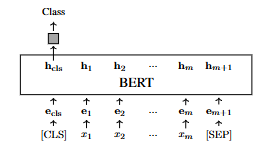

**Ứng dụng:** Sentiment analysis, grammaticality classification, topic classification,...

---

### 2. Text Pair Classification

Ghép hai câu với `[SEP]`, dùng $h_{\text{cls}}$ của chuỗi ghép → classifier:

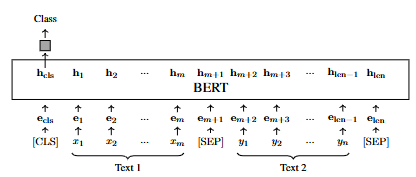

**Ứng dụng:**
- **Semantic equivalence:** Hai câu có cùng nghĩa không?
- **Textual entailment (NLI):** Hypothesis có suy ra từ premise không?
- **Question-Answer matching:** Answer có phù hợp với question không?

---

### 3. Regression

Giống text pair classification nhưng output là **số thực** thay vì label:

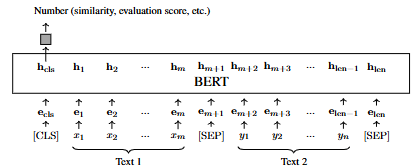

**Ứng dụng:** Sentence similarity scoring, translation quality estimation.

---

### 4. Sequence Labeling

Dự đoán label cho **từng token** — dùng $h_1\ldots h_m$ (không chỉ $h_{\text{cls}}$):

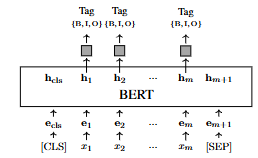

**Loss function:**

$$\text{Loss} = -\frac{1}{m}\sum_{i=1}^m \log p_i(\text{tag}_i) \tag{7.24}$$

**Ứng dụng:** NER (B-ORG, I-ORG, O), POS tagging, word segmentation.

**Inference:** Dynamic programming (Viterbi) để tìm optimal label sequence $O(m)$.

---

### 5. Span Prediction (Reading Comprehension)

Cho query $x_1\ldots x_m$ và context $y_1\ldots y_n$ → tìm span $[j_1, j_2]$ trong context trả lời query.

**Kiến trúc:**

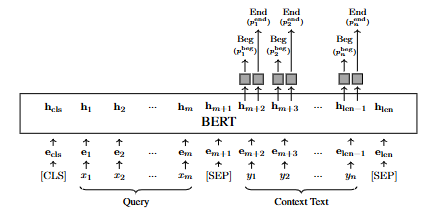

Hai prediction networks riêng biệt tại mỗi vị trí context:
- $p_j^{\text{beg}}$: xác suất $y_j$ là điểm bắt đầu span
- $p_j^{\text{end}}$: xác suất $y_j$ là điểm kết thúc span

**Loss:**

$$\text{Loss} = -\frac{1}{n}\sum_{j=1}^n (\log p_j^{\text{beg}} + \log p_j^{\text{end}}) \tag{7.25}$$

**Inference — tìm span tốt nhất:**

$$(\hat{j}_1, \hat{j}_2) = \arg\max_{1 \leq j_1 \leq j_2 \leq n} (\log p_{j_1}^{\text{beg}} + \log p_{j_2}^{\text{end}}) \tag{7.26}$$

**Ứng dụng:** SQuAD, reading comprehension, machine reading.

---

### 6. Encoder cho Encoder-Decoder (Generation Tasks)

BERT làm source encoder trong seq2seq system:

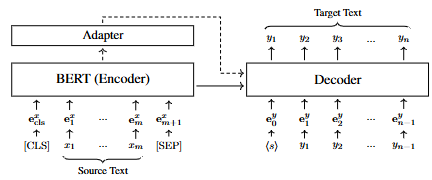

**Adapter:** Module nhỏ map BERT output → format phù hợp với decoder (có thể là linear projection).

**Ứng dụng:** MT, summarization, QA, dialogue — bất kỳ task nào cần hiểu source text tốt.

---

## Vấn Đề Catastrophic Forgetting

Fine-tuning BERT cho task A → performance giảm trên task B (đã fine-tune trước).

**Nguyên nhân:** Gradient updates cho task A làm thay đổi tham số đã tối ưu cho task B.

**Giải pháp:**
- Thêm data cũ vào fine-tuning mới (experience replay)
- Elastic Weight Consolidation (EWC): phạt thay đổi tham số quan trọng
- Multi-task fine-tuning: train đồng thời nhiều tasks

---

## Tổng Kết Mục 7.4

```
BERT Fine-tuning Pipeline:
  Pre-trained BERT (ĥ) + Prediction Network (ω)
       ↓
  Fine-tune trên labeled data D
       ↓
  (ω̃, θ̃) optimized for downstream task

Task Architectures:
  Single Classification:  hcls → Softmax → label
  Pair Classification:    hcls (of concat) → Softmax → label
  Regression:             hcls → Sigmoid → score
  Sequence Labeling:      h₁...hₘ → per-token Softmax → tags
  Span Prediction:        context hj → pbeg, pend per position
  Encoder for Decoder:    BERT encoder + separate decoder
```

| Task | Input Format | Prediction Network | Output |
|---|---|---|---|
| Single Classification | `[CLS] text [SEP]` | Softmax trên $h_{\text{cls}}$ | Label |
| Pair Classification | `[CLS] t1 [SEP] t2 [SEP]` | Softmax trên $h_{\text{cls}}$ | Label |
| Regression | `[CLS] t1 [SEP] t2 [SEP]` | Sigmoid trên $h_{\text{cls}}$ | Score |
| Sequence Labeling | `[CLS] x₁...xₘ [SEP]` | Softmax tại $h_1\ldots h_m$ | Tags |
| Span Prediction | `[CLS] query [SEP] ctx [SEP]` | Beg/End networks | Span $[j_1,j_2]$ |
| Generation | `[CLS] source [SEP]` | Decoder on BERT output | Target sequence |